<a href="https://colab.research.google.com/github/cyeef/Data-Science-Portfolio-C21-/blob/main/Exercises/Project_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Naive Bayes Classification Prediction Aanalysis

---



## Problem Definition


##State the business problem.

Using Transaction.train.big.csv' we intend to determine if we can predict future purchases - will a customer spend or not?

> Two assumptions - variables are not related or correlated! - Gaussian

###Translate the business problem into a Data Science problem by stating what kind of problem it is?

This is supervised learning. We have transactional data with labels. Our labeled transactional data from the data set  indicates that customers purchases = 1 or purchases = 0, this is binary classification problem (1) or (0).

###Classification Model

We use *categorical* in this analysis because we want to determine the binary choice in the data. The target being transaction or not is not continous discreet data.  The data is binary '1' was there a transaction or '0' no transaction. This indicated that it was not a regression model, clustered data.








## Data Collection/Sources


Imported Python libraries - Pandas for dataframes, Numpy for calculations and Matplotlib for graphs and visualizations.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Importing data from AWS S3 Train.csv full reference:
https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv  
The data size was 833.1+ MB used pd.read_csv to extract the data.

In [2]:
df=pd.read_csv("https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv")

## Data Cleaning
Running df.head to get the begging 5 rows of the data set, df.tail to get the last five of the data set and df.shape to see how many rows and columns we have x,y.  This data set contains a million and fiffty thousand entries.  When running df['target'].value_counts() we have 161960 = (0.0) for not a transaction
and only 18040 = (1.0) for a transaction.  In the dataset we also million plus NaN cells.  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB



In [3]:
df.head(6)

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,train_5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520


In [4]:
df.tail(6)

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049994,1049994,train_1049994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690


The method df.shape is telling us that we have 1050000 rows and 104 columns in the dataset.

In [5]:
df.shape

(1050000, 104)

The dtypes are float(102), int64(1) which is labeld as target column with binary data 1 and 0 or NaN, and object(1).

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB


Using method isnull() gave us the following count of NaN in the dataset.

In [7]:
print(df.isnull().sum())

Unnamed: 0          0
ID_code             0
target         870000
var_0          870000
var_1          870000
               ...   
var_96        1050000
var_97        1050000
var_98        1050000
var_99        1050000
var_100        870000
Length: 104, dtype: int64


Our *target* binary values of 1, 0 are 0.0 = 161960 and 1.0 = **18040**

In [8]:
df['target'].value_counts()

,count
target,
0.0,161960
1.0,18040


The .duplicated will show if we have any duplicated values, we do not. Since NaN, none, na mean no data these would not be consideed duplicated.  No values in the rows or columns is no value no data.

In [9]:
df.duplicated().sum()

np.int64(0)

Drop na which is python removing cells that have no data, NaN, or blank cells. I tried using .dropna() and ended up with a shape of (0, 104) this tells me that we lost significant 'target values.



In [10]:
#df = df.dropna()
print(df.shape)

(1050000, 104)


Further research suggest that I should use df = df[df['target'].notna()] to keep necessary columns because when I .dropna the I ended up zero rows and 104 columns.



In [11]:
df = df[df['target'].notna()]
print(df.shape)

(180000, 104)


Columns var_96 thru var_99 have NaN, no data or na so .drop() helps remove these columns without eliminating columns with data and NaN values.   To check shape I will also df.shape() - got KeyError KeyError: "['var_97', 'var_98', 'var_99'] not found in axis"  Will use print(df.columns.tolist())

In [12]:
print(df.columns.tolist())

# df = df.drop(columns=['var_91', 'var_97', 'var_98', 'var_99']) this wipped all columns with nulls and data
print(df.shape)

['Unnamed: 0', 'ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_14', 'var_15', 'var_16', 'var_17', 'var_18', 'var_19', 'var_20', 'var_21', 'var_22', 'var_23', 'var_24', 'var_25', 'var_26', 'var_27', 'var_28', 'var_29', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_36', 'var_37', 'var_38', 'var_39', 'var_40', 'var_41', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_48', 'var_49', 'var_50', 'var_51', 'var_52', 'var_53', 'var_54', 'var_55', 'var_56', 'var_57', 'var_58', 'var_59', 'var_60', 'var_61', 'var_62', 'var_63', 'var_64', 'var_65', 'var_66', 'var_67', 'var_68', 'var_69', 'var_70', 'var_71', 'var_72', 'var_73', 'var_74', 'var_75', 'var_76', 'var_77', 'var_78', 'var_79', 'var_80', 'var_81', 'var_82', 'var_83', 'var_84', 'var_85', 'var_86', 'var_87', 'var_88', 'var_89', 'var_90', 'var_91', 'var_92', 'var_93', 'var_94', 'var_95', 'var_96', 'var

In [13]:
print(df.columns[df.isnull().all()].tolist())

['var_3', 'var_5', 'var_6', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_16', 'var_18', 'var_19', 'var_23', 'var_25', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_40', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_50', 'var_51', 'var_53', 'var_54', 'var_55', 'var_58', 'var_59', 'var_60', 'var_64', 'var_68', 'var_69', 'var_71', 'var_74', 'var_76', 'var_77', 'var_79', 'var_81', 'var_90', 'var_91', 'var_93', 'var_95', 'var_96', 'var_97', 'var_98', 'var_99']


In [14]:
print(df.isnull().sum().sum())

9180000


This line of code summed the null values and determined if the column had more than one null > 0.    

In [15]:
print(df.isnull().sum()[df.isnull().sum() > 0])

var_3     180000
var_5     180000
var_6     180000
var_9     180000
var_10    180000
var_11    180000
var_12    180000
var_13    180000
var_16    180000
var_18    180000
var_19    180000
var_23    180000
var_25    180000
var_30    180000
var_31    180000
var_32    180000
var_33    180000
var_34    180000
var_35    180000
var_40    180000
var_42    180000
var_43    180000
var_44    180000
var_45    180000
var_46    180000
var_47    180000
var_50    180000
var_51    180000
var_53    180000
var_54    180000
var_55    180000
var_58    180000
var_59    180000
var_60    180000
var_64    180000
var_68    180000
var_69    180000
var_71    180000
var_74    180000
var_76    180000
var_77    180000
var_79    180000
var_81    180000
var_90    180000
var_91    180000
var_93    180000
var_95    180000
var_96    180000
var_97    180000
var_98    180000
var_99    180000
dtype: int64


This kept 180000 rows and 53 columns with data 47 columns were dropped.

In [16]:
null_cols = df.columns[df.isnull().all()].tolist()
df = df.drop(columns=null_cols)

print(f"Dropped {len(null_cols)} fully null columns")
print(df.shape)

Dropped 51 fully null columns
(180000, 53)


Confirming if NA, and NaN are gone and if duplicates remain (0,0)

In [17]:
print(df.isnull().sum().sum())
print(df.duplicated().sum())

0
0


## Exploratory Data Analysis


Checking if values are equally distributed and using DS naming convention *'predictor*' and creating new variable predictors instead of df - data is roughly symmetric and bell shaped, and centered around the mean of each variable.

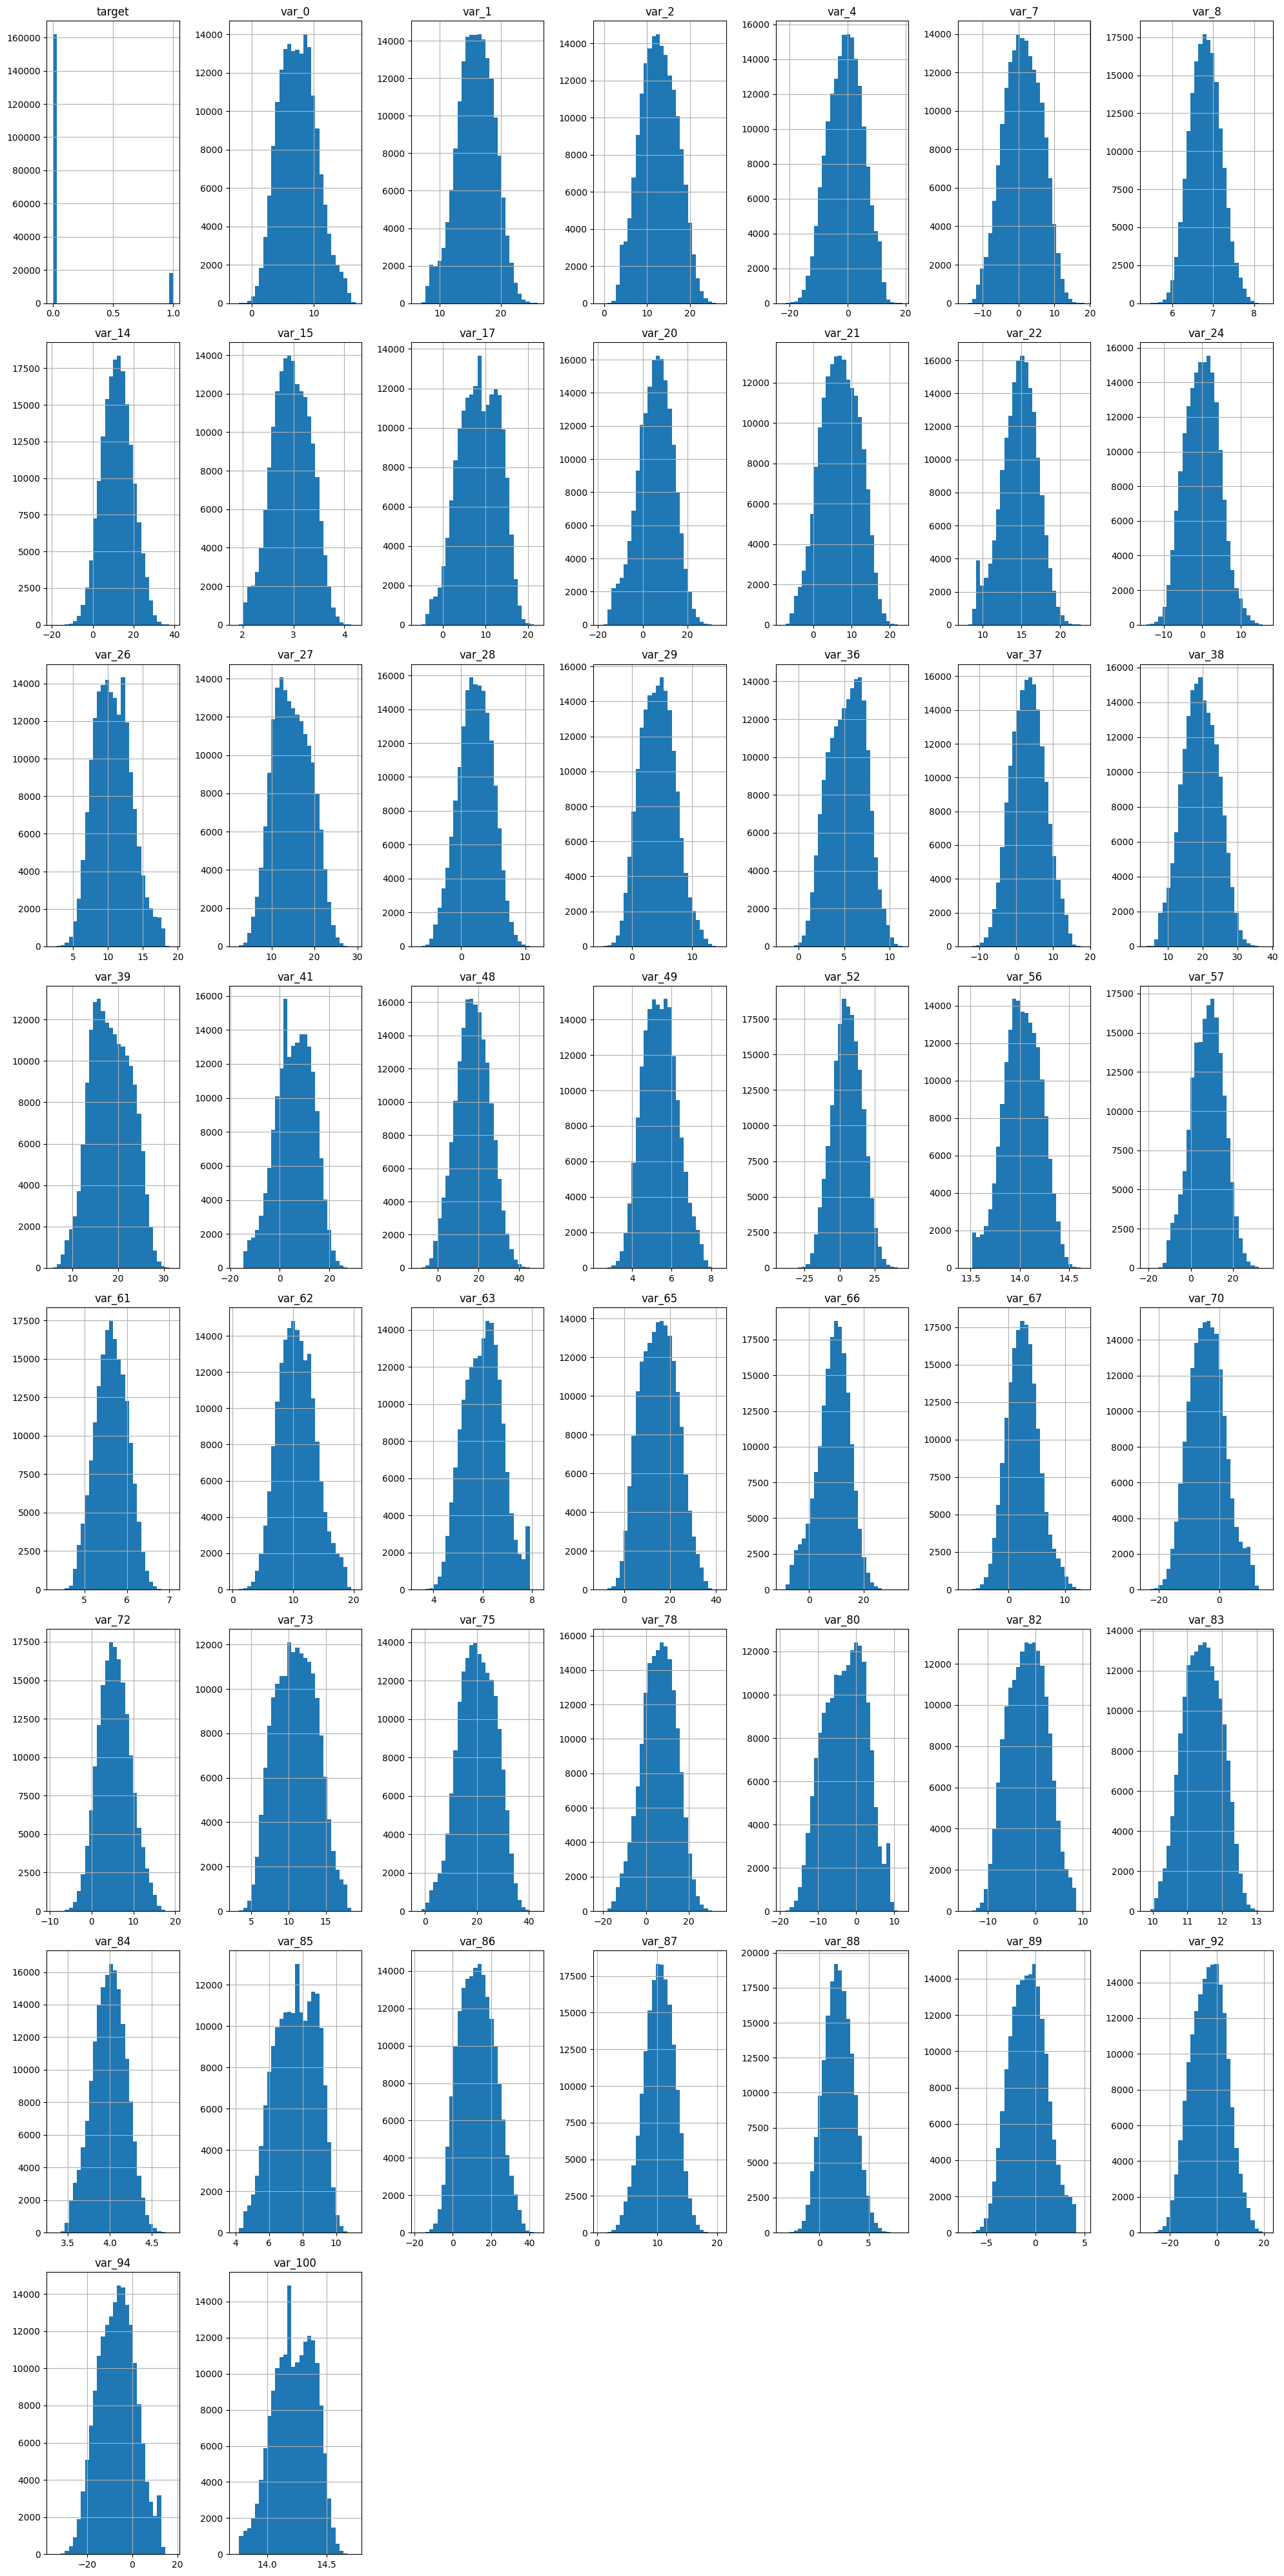

In [37]:

predictors = df.drop(columns=['Unnamed: 0', 'ID_code'])

predictors.hist(figsize=(20, 40), bins=30)
plt.tight_layout()
plt.show()

Data shows 161960 zeros which is binary for ' did not transact' 18040 ones for did transact the data type is still int64 [0. 1.] -

In [40]:
print(df['target'].value_counts())
print(df['target'].unique())
print(df.describe)

target
0.0    161960
1.0     18040
Name: count, dtype: int64
[0. 1.]
<bound method NDFrame.describe of          Unnamed: 0        ID_code  target    var_0    var_1    var_2   var_4  \
3                 3        train_3     0.0   4.6739  22.3915  15.6015  0.0464   
5                 5        train_5     0.0  14.6962  18.3383  17.4788 -9.1355   
11               11       train_11     0.0   4.4949  14.4142  13.2219  4.9140   
15               15       train_15     0.0   4.9657  16.2867  17.9579  0.6017   
19               19       train_19     0.0   9.4287  18.7822  10.7630 -0.7532   
...             ...            ...     ...      ...      ...      ...     ...   
1049990     1049990  train_1049990     0.0   7.9632  20.4650  10.7295  2.9322   
1049993     1049993  train_1049993     0.0   5.0862  14.4785  17.3709 -2.4732   
1049995     1049995  train_1049995     1.0  11.3251  16.4148  20.5955 -6.3011   
1049997     1049997  train_1049997     0.0   8.9941  13.4127   3.9567  3.5744   
104999

Checking to see if we proportion in the data - looks to be more non-transactions then transactions (89.83,10) respectfully.

In [20]:
perct = (161690/180000)*100
perct1 = (18040/180000)*100
print(perct, perct1)

89.82777777777777 10.022222222222222


Additional code check on the target values.

In [21]:
print(df['target'].value_counts(normalize = True) * 100)
print(df)

target
0.0    89.977778
1.0    10.022222
Name: proportion, dtype: float64
         Unnamed: 0        ID_code  target    var_0    var_1    var_2   var_4  \
3                 3        train_3     0.0   4.6739  22.3915  15.6015  0.0464   
5                 5        train_5     0.0  14.6962  18.3383  17.4788 -9.1355   
11               11       train_11     0.0   4.4949  14.4142  13.2219  4.9140   
15               15       train_15     0.0   4.9657  16.2867  17.9579  0.6017   
19               19       train_19     0.0   9.4287  18.7822  10.7630 -0.7532   
...             ...            ...     ...      ...      ...      ...     ...   
1049990     1049990  train_1049990     0.0   7.9632  20.4650  10.7295  2.9322   
1049993     1049993  train_1049993     0.0   5.0862  14.4785  17.3709 -2.4732   
1049995     1049995  train_1049995     1.0  11.3251  16.4148  20.5955 -6.3011   
1049997     1049997  train_1049997     0.0   8.9941  13.4127   3.9567  3.5744   
1049999     1049999  train_1049999 

Check for correlation.  Are the binary values correlated or independent of each other?  Gaussian Navie Bayes assumption.  Independent and not correlated. We are looking for linear relationships; Positive, negative or no correlation.  Using .corr() and for absolute values .abs() to detect both directions of relationship if any.  .corr() = (50, 50) our matrix is equally proportioned within the predictor variables, and the Gaussian Naive Bayes is False so the data is independent and not correlated.

In [22]:
corr_matrix = predictors.corr()
print(corr_matrix.shape)

(50, 50)


Testing if the values in the variables are correlated.  > 0.5 test to see if the values are closer to one.  The != 1.0 says each value that correlates itself should be ignored. The grey indicates no values are correlated with other values. Bayes assumption that varriables are indpendent is shown.

In [38]:
high_corr = (corr_matrix.abs() > 0.5) & (corr_matrix != 1.0)
print(high_corr.any().any())

False


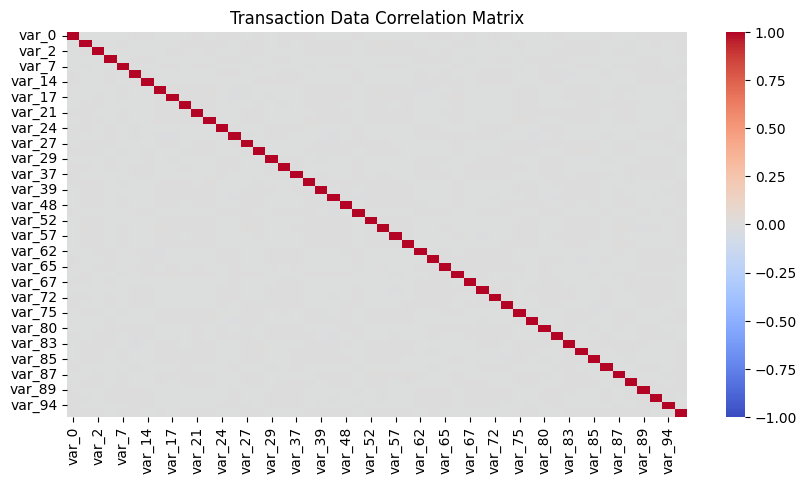

In [59]:
import seaborn as sns


plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            vmin=-1,
            vmax=1)
plt.title('Transaction Data Correlation Matrix')
plt.show()


Deermine the shape of values in each df we have 18040 transactions and 53 colunms and 161960 non transactions, with 53 columns.

In [24]:
df_transaction = df[df['target'] == 1.0].copy()
df_non_transaction = df[df['target'] == 0.0].copy()

print(df_transaction.shape)
print(df_non_transaction.shape)

(18040, 53)
(161960, 53)


## Processing



Create x and y.  X is the inputs of all the columns of anonymized transactions data, and Y will be our target column (1, 0) and determine our prediction - can we predict future transactions based on previous transactions?

In [25]:
X = df.drop(columns=['Unnamed: 0', 'ID_code', 'target']).copy()
y = df['target'].copy()

print(X.shape)
print(y.shape)

(180000, 50)
(180000,)


Using sklearn.naive_bayes create a model.

In [26]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
print(model)

GaussianNB()


This is the training and testing part, we will split the data into two sets.  180,000 rows will be split using 810 % or 144,000 rows to train, and 20% of the rows to test the data.  We will cross-validate more than one time to increase accuracy of the model.

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
#print(y_train.shape)
#print(y_test.shape)

(144000, 50)
(36000, 50)


The model 'fitted' or trained successsfully lerning the realationship between the predictor variables and the target column.  

In [28]:
model.fit(X_train, y_train)

GaussianNB()

The model accuratly predicts the target value (0) 90%  of the time.  

In [29]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9109166666666667


Cross valdiation shows 90% indication that target value (0) will consitently occur 90% of the time.

In [30]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(f"Cross-validation scores: {scores}")
print(f"Mean accuracy: {scores.mean()}")

Cross-validation scores: [0.91066667 0.91186111 0.91038889 0.91119444 0.91252778]
Mean accuracy: 0.9113277777777778


We have accurate data that has low variance, the data is trained and tested with consistent results at about 91 percent with low variation between the five cross validation tests.  This 91% is linked to the many more target values of 0 - target value 1 is 10 percent of the total data set and the model will consistently predict 0 over 1.

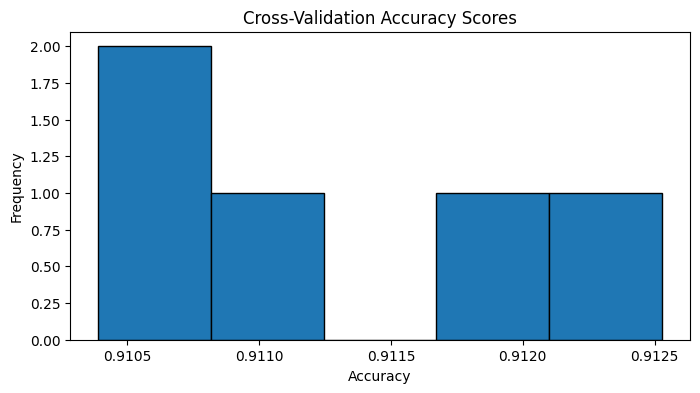

In [31]:
plt.figure(figsize=(8, 4))
plt.hist(scores, bins=5, edgecolor='black')
plt.title('Cross-Validation Accuracy Scores')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()

This output was generated by Claude AI to help me understand the confusion and classification matrix.  We are at 2,788 missed target (1) values.  

Target 0 (no transaction):
- Precision 0.92 → when it says no transaction, right 92% of time
- Recall    0.99 → finds 99% of all actual no-transactions
- F1        0.95 → excellent ✅

Target 1 (transaction):
- Precision 0.66 → when it says transaction, right 66% of time
- Recall    0.23 → only finds 23% of actual transactions ❌
- F1        0.34 → very poor ❌

In [32]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[31983   419]
 [ 2788   810]]
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     32402
         1.0       0.66      0.23      0.34      3598

    accuracy                           0.91     36000
   macro avg       0.79      0.61      0.64     36000
weighted avg       0.89      0.91      0.89     36000



Sampling was done on the non_transaction rows (target value 0) to create a balanced dataset were 50% of target values will be (0) and the other 50 percent will be (1).  The balancing will help the model learn both sides of the data so that training and testing will be more accurate.

In [33]:
df_balanced = pd.concat([
    df_transaction,
    df_non_transaction.sample(n=len(df_transaction), random_state=42)
])

print(df_balanced['target'].value_counts())
print(df_balanced.shape)

target
1.0    18040
0.0    18040
Name: count, dtype: int64
(36080, 53)


Cross validation - is the model balanced

The mean balance between target values 1, 0 shows that the model is not sampling target value 0 at a higher rate, which it defaulted to at the 91% rate.

In [34]:
X_bal = df_balanced.drop(columns=['Unnamed: 0', 'ID_code', 'target']).copy()
y_bal = df_balanced['target'].copy()

scores_bal = cross_val_score(model, X_bal, y_bal, cv=5)
print(f"Balanced CV scores: {scores_bal}")
print(f"Balanced mean accuracy: {scores_bal.mean()}")

Balanced CV scores: [0.75207871 0.75970067 0.74833703 0.75207871 0.75817627]
Balanced mean accuracy: 0.7540742793791574


## Data Visualization/Communication of Results


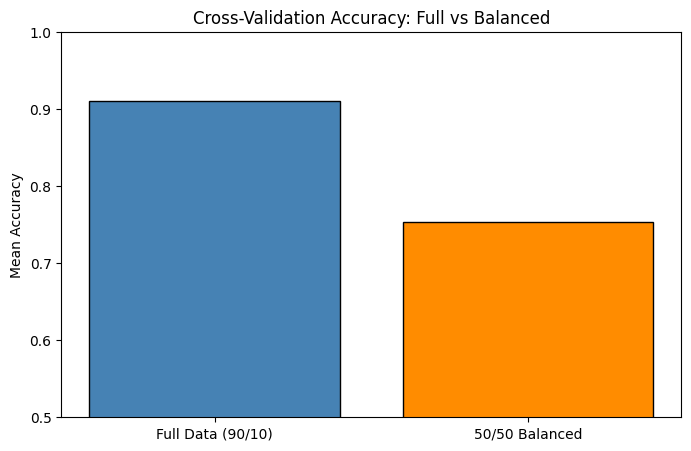

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(['Full Data (90/10)', '50/50 Balanced'],
        [scores.mean(), scores_bal.mean()],
        color=['steelblue', 'darkorange'],
        edgecolor='black')
plt.title('Cross-Validation Accuracy: Full vs Balanced')
plt.ylabel('Mean Accuracy')
plt.ylim(0.5, 1.0)
plt.show()

This balance test shows more tested and trained data on the target value 1.  f1 scores have imporved in both target (1, 0).  Target 0 F1 scores went down and Target 1 F1 scores went up.  

In [36]:
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42)

model.fit(X_train_bal, y_train_bal)
y_pred_bal = model.predict(X_test_bal)

print(confusion_matrix(y_test_bal, y_pred_bal))
print(classification_report(y_test_bal, y_pred_bal))

[[2759  845]
 [ 917 2695]]
              precision    recall  f1-score   support

         0.0       0.75      0.77      0.76      3604
         1.0       0.76      0.75      0.75      3612

    accuracy                           0.76      7216
   macro avg       0.76      0.76      0.76      7216
weighted avg       0.76      0.76      0.76      7216



# Results

The model performed as expected. It selected values with higher frequency in the dataset. This produced an imbalance in the training and testing of the model. The confusion matrix in both tests indicated that the data was skewed toward the Target 0 values, which would have indicated no future transactions.

Cross validation tests were at 91 % with low variance between the outputs, suggesting the model was highly selective of Target 0 values, creating a bias in the output.

1.   Predicting no_futrue transaction 91% of the time.
2.   Class imbalance of 90/10 (0 / 1)

The second cross validation test was more balanced, and data selection was less biased toward the Target value 0, which was indicated by the five cross validation tests. The second cross validation test showed increased selection of Target 1 values indicating that the model had improved precision, recall, and F1 scores at 75%.

1.   More balance in the dataset 50/50
2.   F1 scores improved to 75%

The models’ limitations is tied to the data. The higher the frequency of values within a data set the more likely the model will select for those values, requiring more cross validation, testing and training until some balance and increased variance in selection is made.  

